# Dependencies

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib
import os

# understand what our CSV

In [2]:
# Construct the correct path to the CSV file
# This goes up one level from 'notebooks', then down into 'data'
data_path = os.path.join('..', 'data', 'Crop_recommendation.csv')

# Read the data using pandas
df = pd.read_csv(data_path)

# Display the first 5 rows to see what it looks like
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [4]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


# Performing EDA ~

In [14]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid') # Using seaborn darkgrid for a clean look
# You can also try 'ggplot', 'fivethirtyeight', 'bmh'

In [15]:
print("Starting Exploratory Data Analysis (EDA) on the Crop Recommendation Dataset... 📈\n")


Starting Exploratory Data Analysis (EDA) on the Crop Recommendation Dataset... 📈



In [16]:
try:
    df = pd.read_csv(data_path)
    print(f"Dataset loaded successfully from: {data_path} ✅")
except FileNotFoundError:
    print(f"Error: '{data_path}' not found. Please ensure the CSV file is in the correct directory. ❌")
    print("Expected path (relative to your notebook): CropGuru/ml_model/data/Crop_recommendation.csv")
    exit() # Exit the script if the file isn't found

Dataset loaded successfully from: ../data/Crop_recommendation.csv ✅


In [17]:
# --- 2. Initial Data Inspection (as you previously ran) ---
print("\n--- Initial Dataframe Information ---")
df.info()
print("\nThis provides a quick overview of column names, non-null counts, and data types.")



--- Initial Dataframe Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

This provides a quick overview of column names, non-null counts, and data types.


In [18]:
print("\n--- First 5 Rows of the Dataset ---")
print(df.head())
print("\nViewing the top rows helps to quickly understand the data's structure and content.")




--- First 5 Rows of the Dataset ---
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Viewing the top rows helps to quickly understand the data's structure and content.


In [19]:
print("\n--- Summary Statistics of Numerical Columns ---")
print(df.describe())
print("\nDescriptive statistics give insights into the central tendency, dispersion, and shape of numerical features.")



--- Summary Statistics of Numerical Columns ---
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.

In [20]:
print("\n--- Unique Crop Types (Labels) ---")
unique_crops = df['label'].unique()
print(unique_crops)
print(f"\nThere are {len(unique_crops)} unique crop types in the dataset.")



--- Unique Crop Types (Labels) ---
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']

There are 22 unique crop types in the dataset.



--- Plotting: Distribution of Crop Types ---


/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/706505389.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=df, order=df['label'].value_counts().index, palette='viridis')


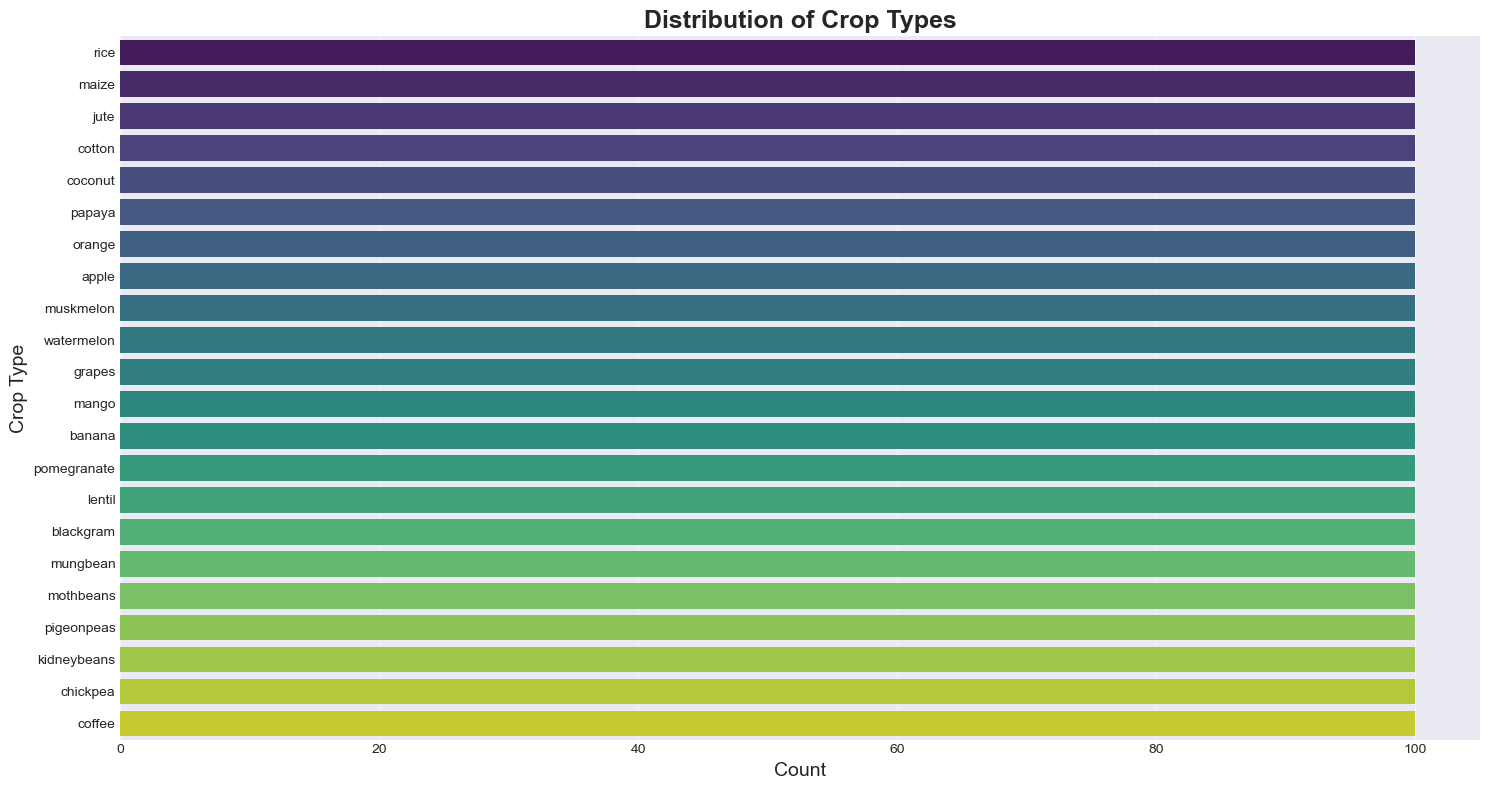

Insight: This chart clearly shows that each of the 22 crop types is equally represented with 100 samples each. This is a well-balanced dataset for classification tasks. 📊


In [21]:
# --- 3. Univariate Analysis: Distribution of Crop Types ---
print("\n--- Plotting: Distribution of Crop Types ---")
plt.figure(figsize=(15, 8))
# Count plot to show the frequency of each crop type
sns.countplot(y='label', data=df, order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribution of Crop Types', fontsize=18, fontweight='bold')
plt.xlabel('Count', fontsize=14)
plt.ylabel('Crop Type', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Insight: This chart clearly shows that each of the 22 crop types is equally represented with 100 samples each. This is a well-balanced dataset for classification tasks. 📊")



--- Plotting: Distribution of Numerical Features (Histograms) ---


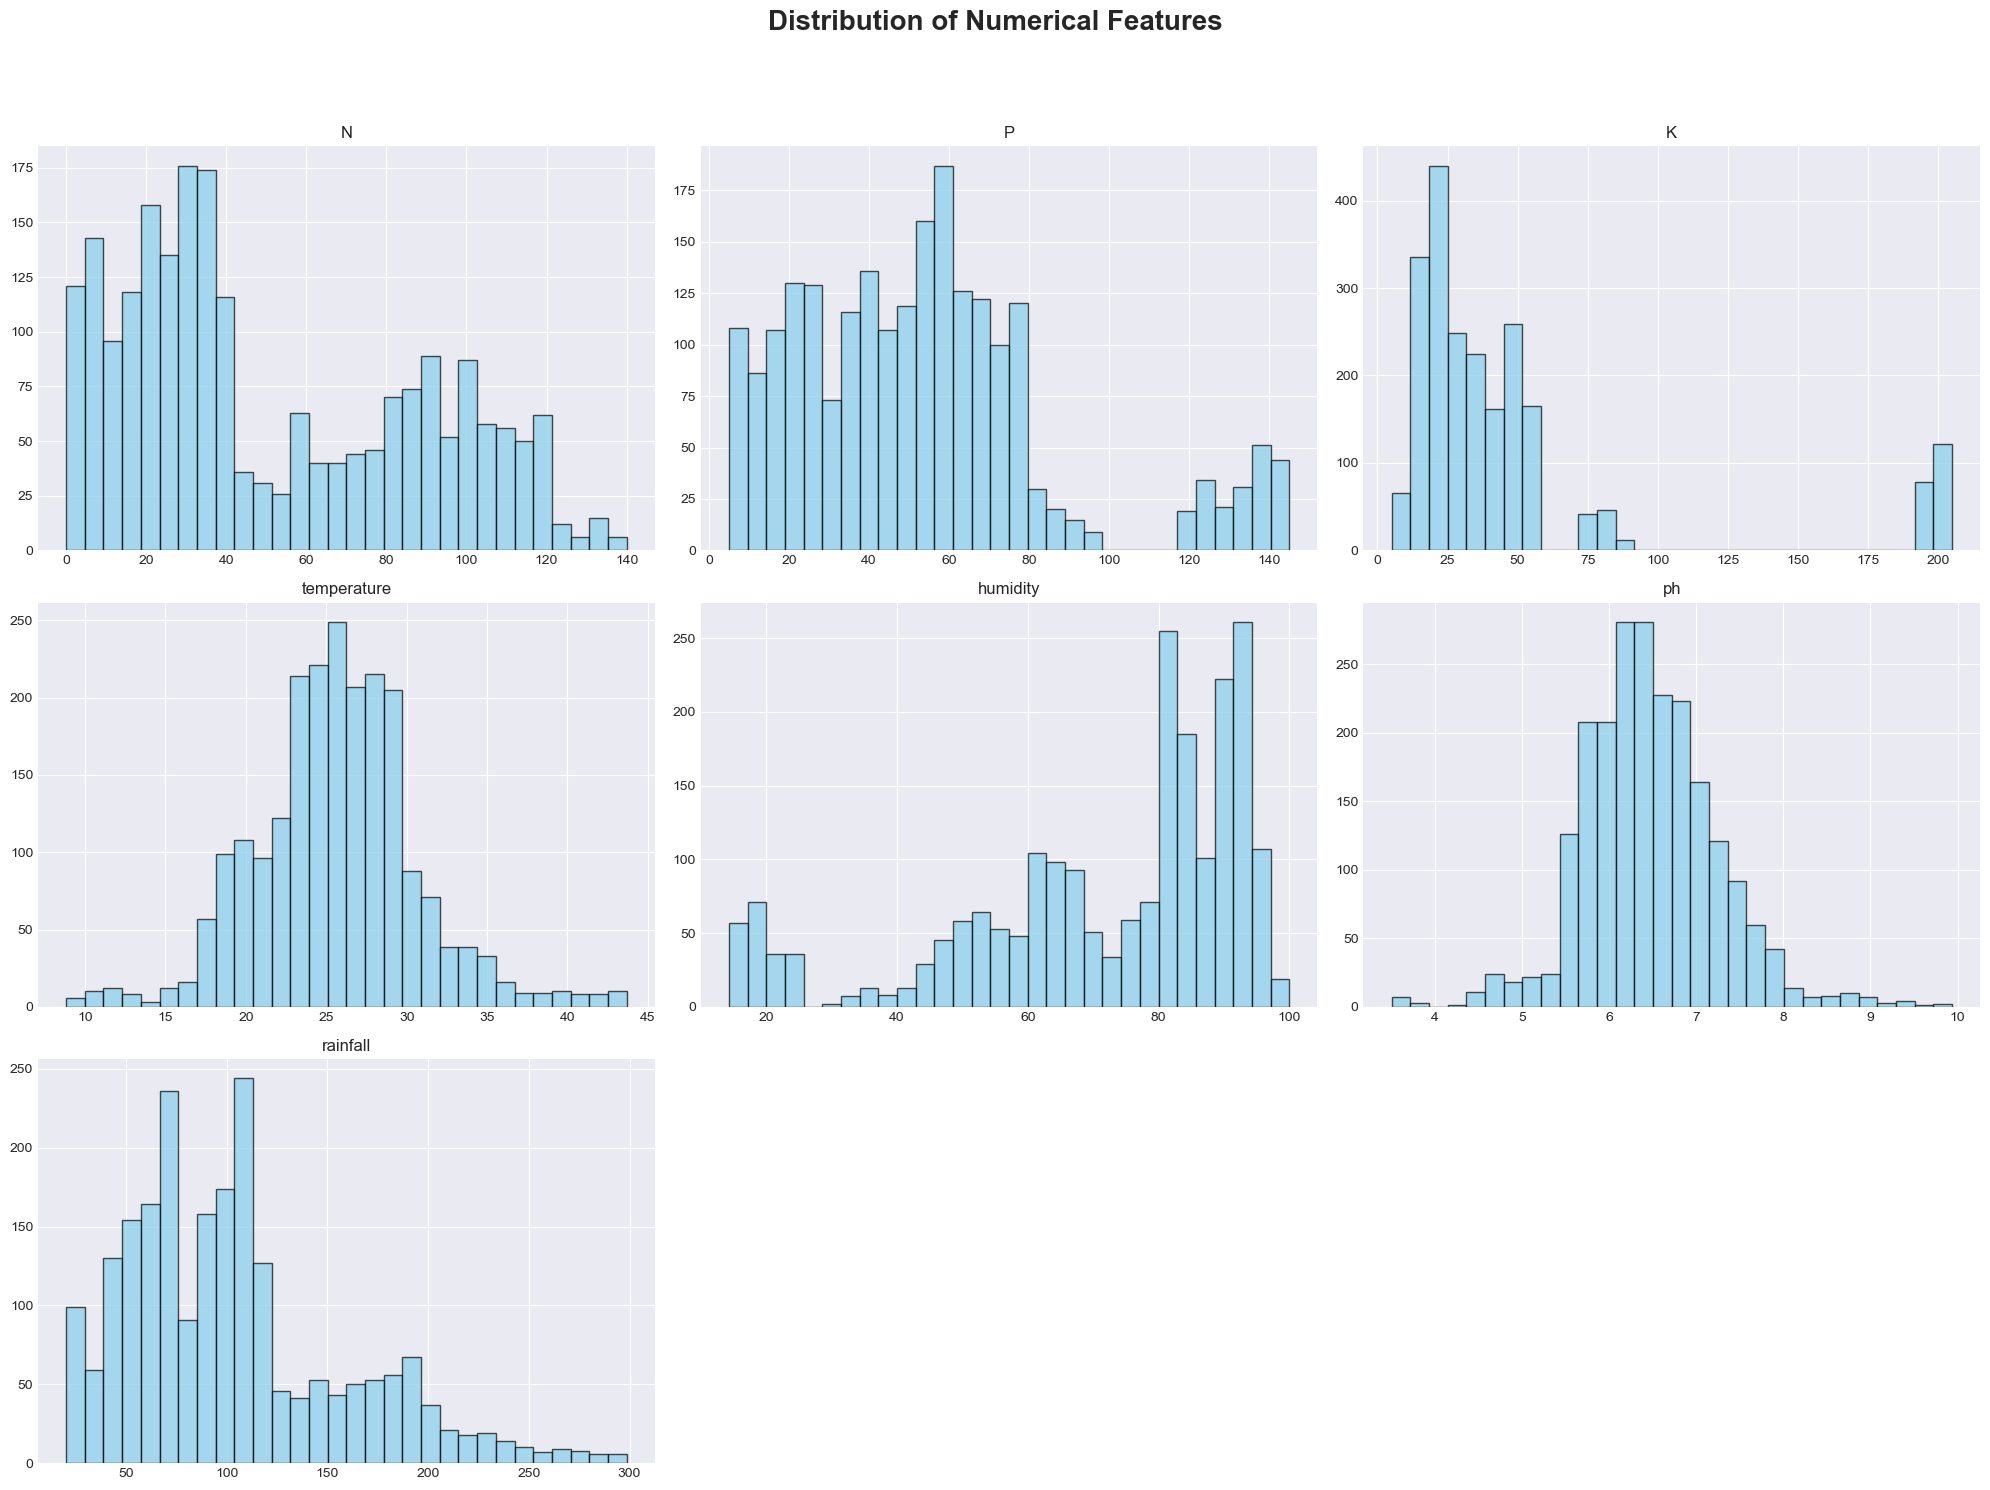

Insight: These histograms display the frequency distribution of each environmental and nutrient factor. They help in understanding the range and common values for each feature, identifying any skewed distributions or potential outliers. 📈


In [22]:
# --- 4. Univariate Analysis: Distribution of Numerical Features ---
print("\n--- Plotting: Distribution of Numerical Features (Histograms) ---")
numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
# Create histograms for each numerical feature to show their distributions
df[numerical_features].hist(bins=30, figsize=(20, 15), edgecolor='black', color='skyblue', alpha=0.7)
plt.suptitle('Distribution of Numerical Features', y=1.02, fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()
print("Insight: These histograms display the frequency distribution of each environmental and nutrient factor. They help in understanding the range and common values for each feature, identifying any skewed distributions or potential outliers. 📈")



--- Plotting: Correlation Matrix of Numerical Features ---


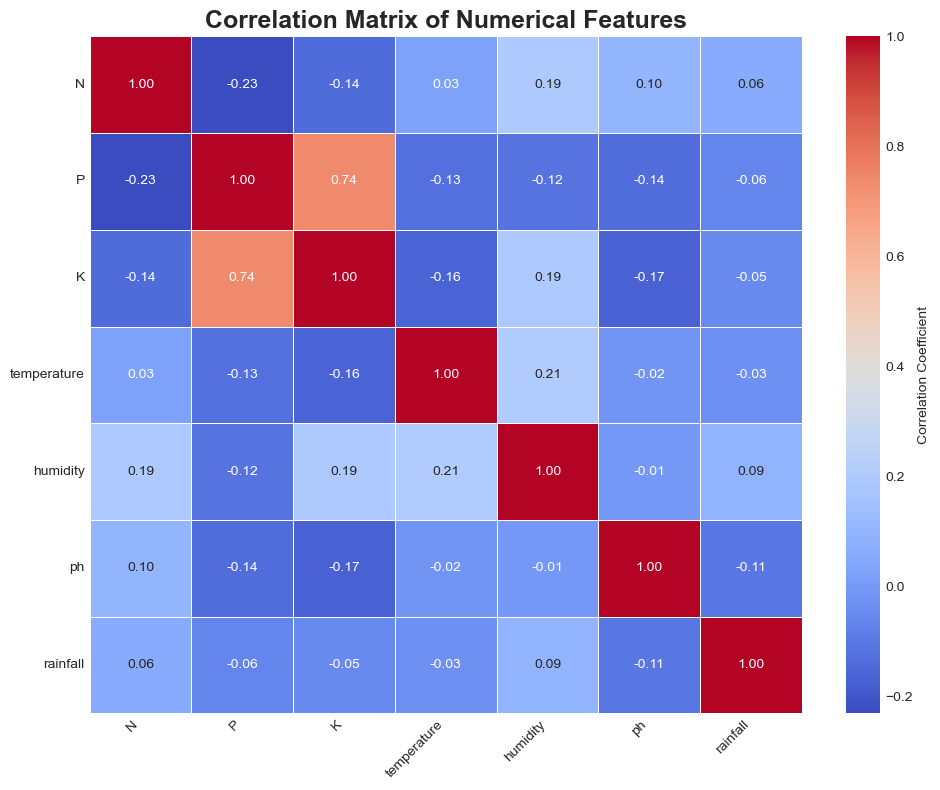

Insight: The heatmap reveals the linear relationships between the numerical variables. A notable positive correlation is observed between 'P' (Phosphorus) and 'K' (Potassium), suggesting that these two nutrients often co-vary. 🔗


In [23]:
# --- 5. Bivariate Analysis: Correlation Heatmap ---
print("\n--- Plotting: Correlation Matrix of Numerical Features ---")
plt.figure(figsize=(10, 8))
# Calculate the correlation matrix
correlation_matrix = df[numerical_features].corr()
# Create a heatmap to visualize the correlations between numerical features
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Numerical Features', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("Insight: The heatmap reveals the linear relationships between the numerical variables. A notable positive correlation is observed between 'P' (Phosphorus) and 'K' (Potassium), suggesting that these two nutrients often co-vary. 🔗")



--- Plotting: Feature Distribution Across Different Crop Types (Box Plots) ---


/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/3050303824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='Spectral')


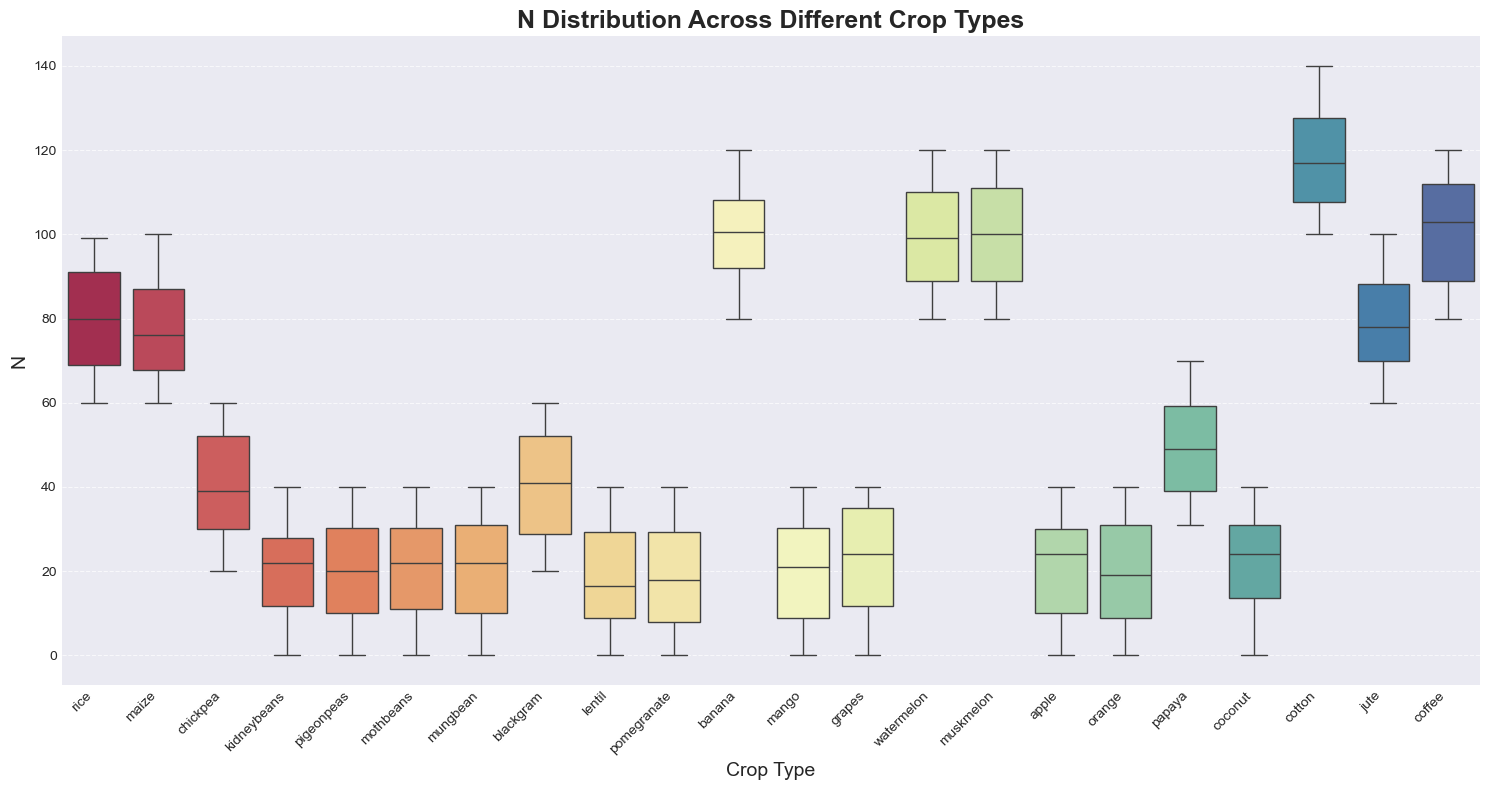

Insight for N: These box plots are crucial for understanding the ideal range of values for 'N' required by each specific crop. They visually highlight the distinct environmental and nutrient preferences of different crops. 🌱


/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/3050303824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='Spectral')


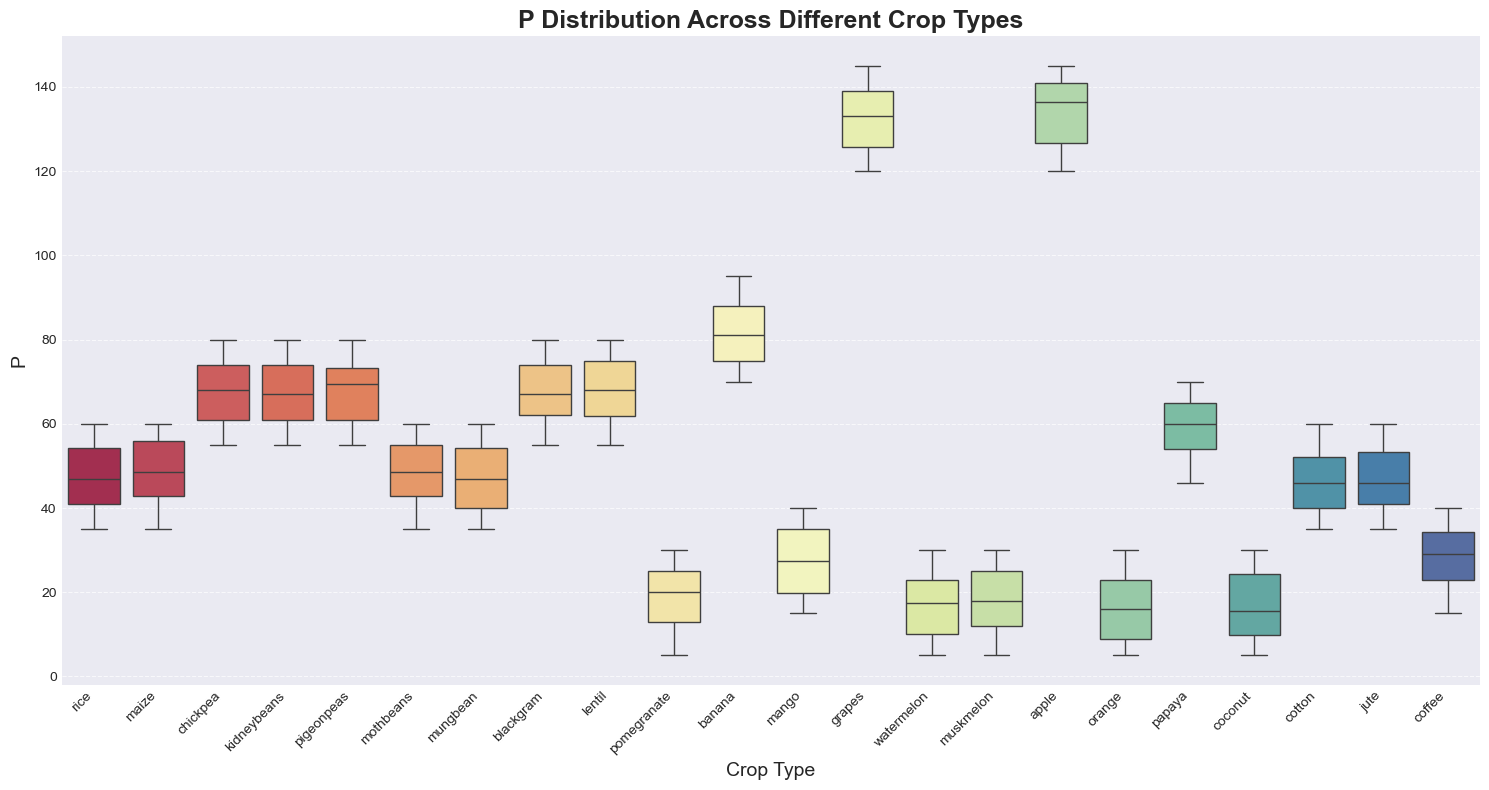

Insight for P: These box plots are crucial for understanding the ideal range of values for 'P' required by each specific crop. They visually highlight the distinct environmental and nutrient preferences of different crops. 🌱


/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/3050303824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='Spectral')


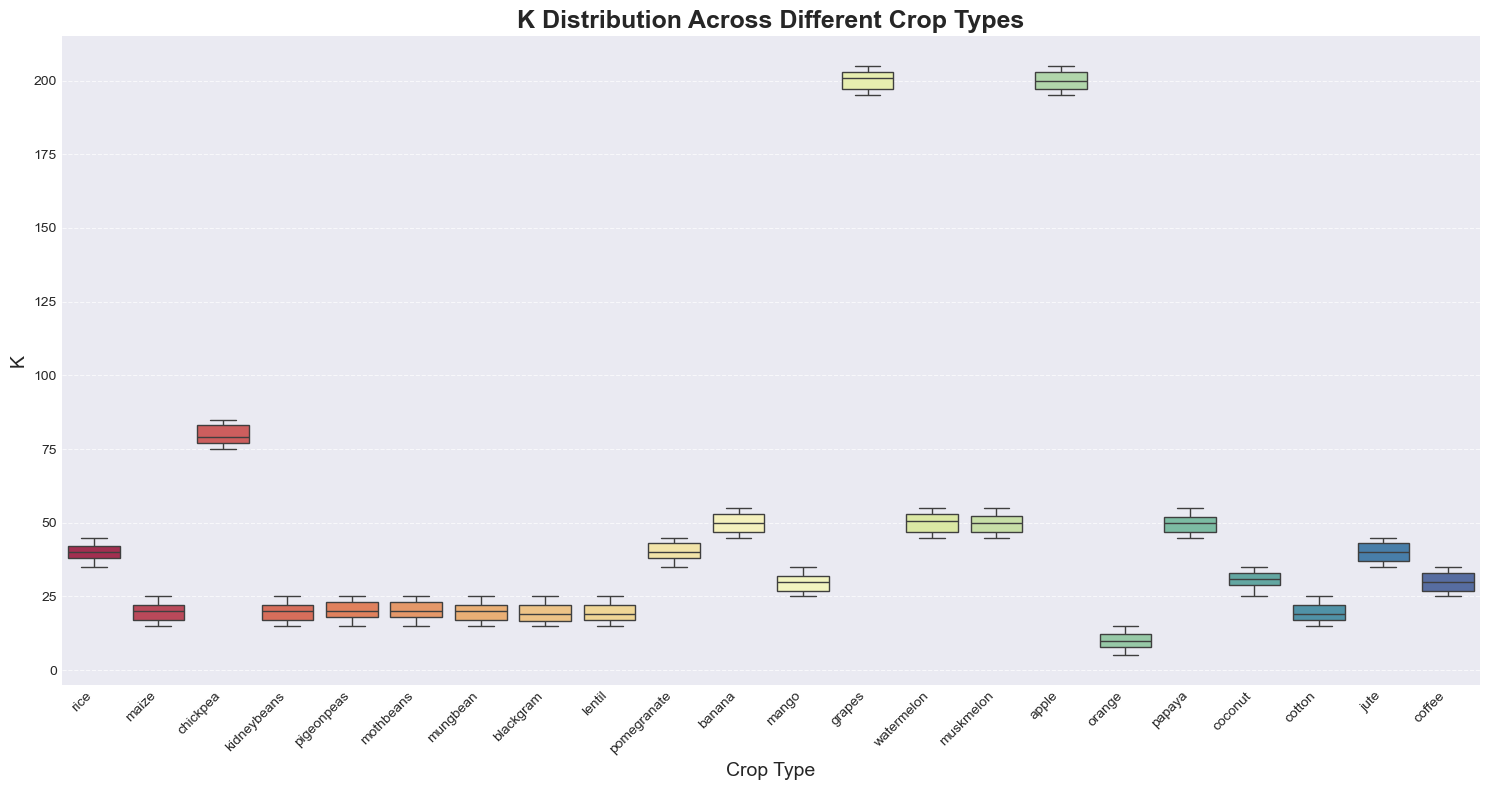

Insight for K: These box plots are crucial for understanding the ideal range of values for 'K' required by each specific crop. They visually highlight the distinct environmental and nutrient preferences of different crops. 🌱


/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/3050303824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='Spectral')


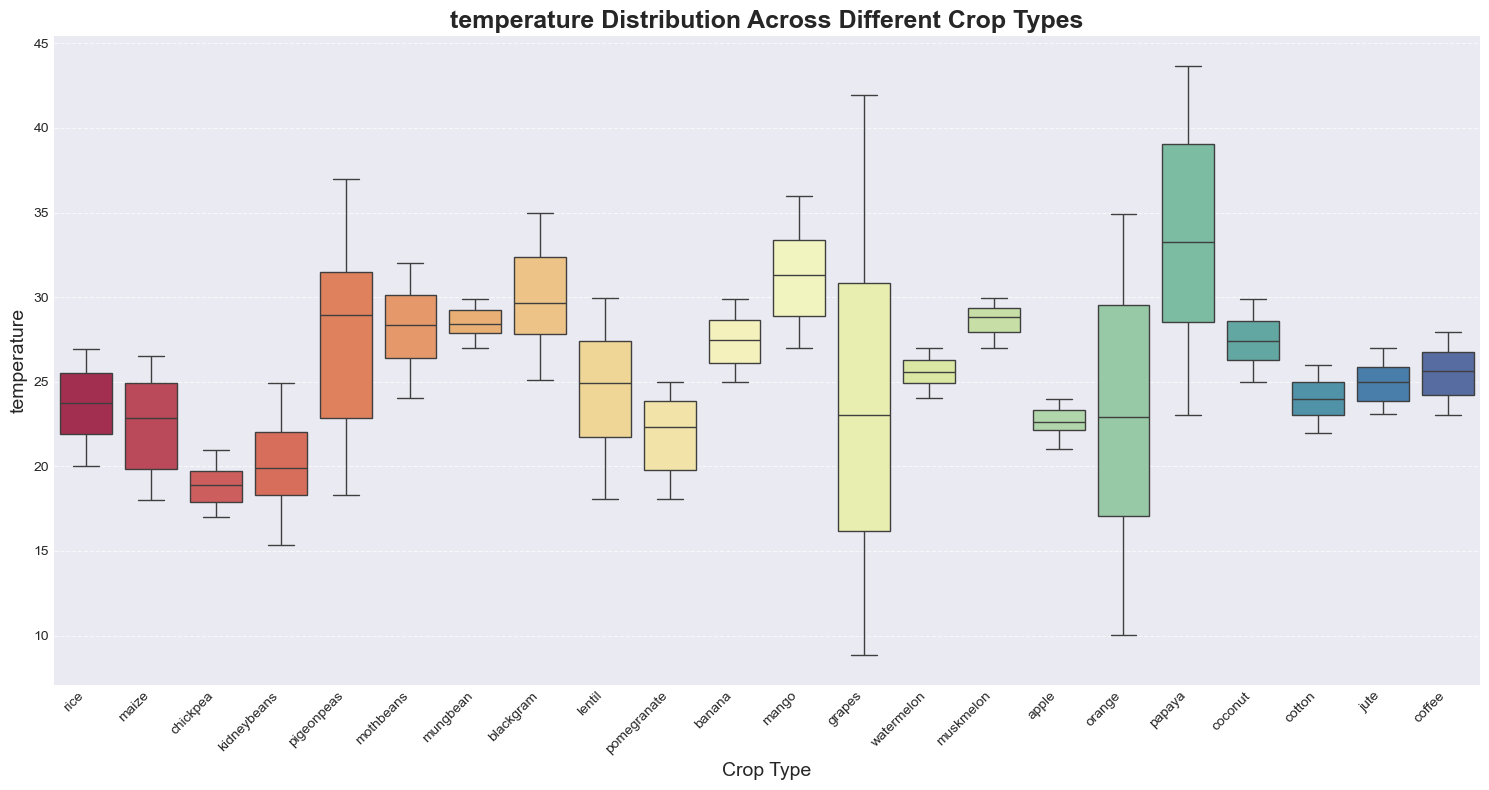

Insight for temperature: These box plots are crucial for understanding the ideal range of values for 'temperature' required by each specific crop. They visually highlight the distinct environmental and nutrient preferences of different crops. 🌱


/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/3050303824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='Spectral')


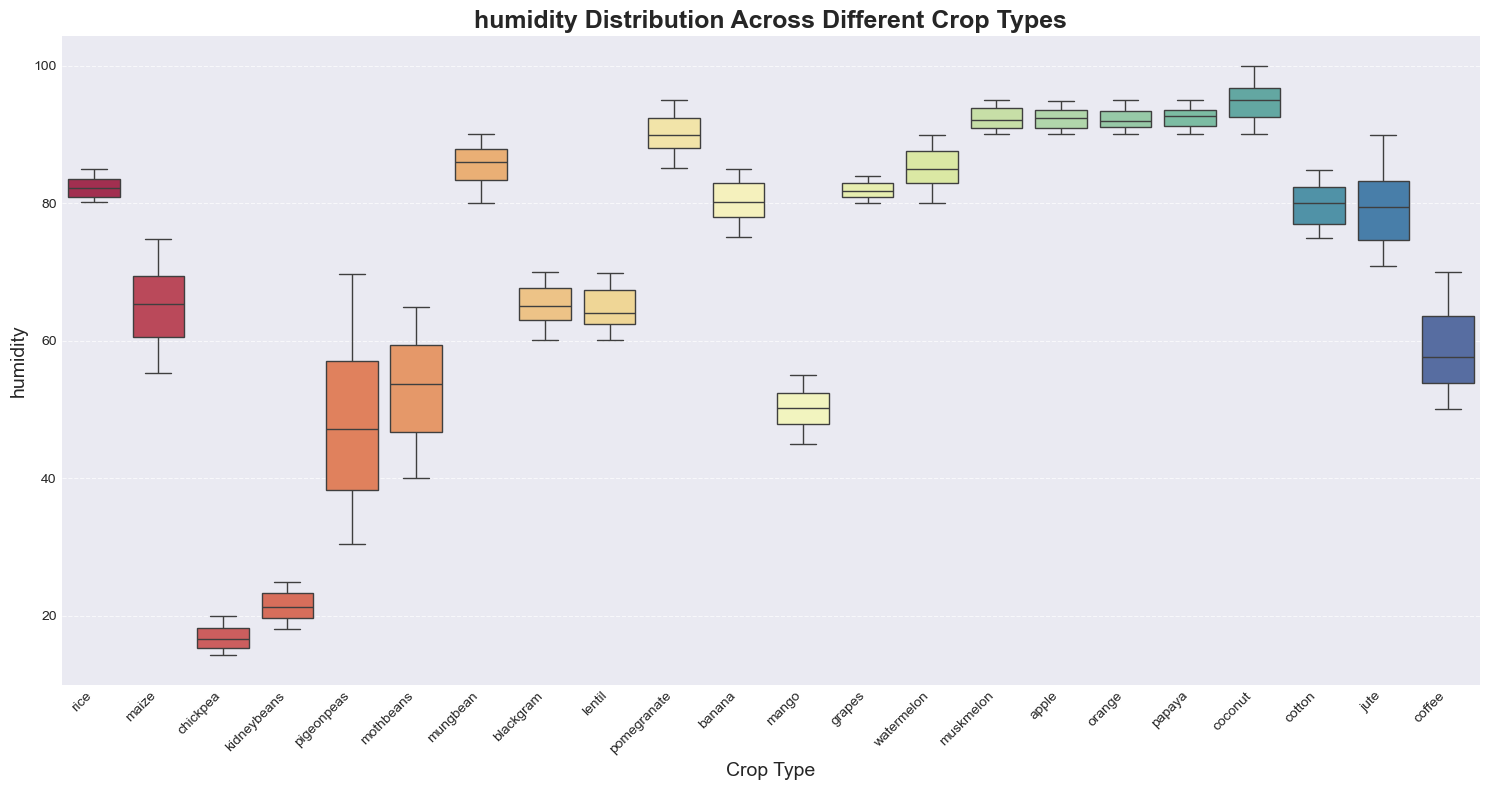

Insight for humidity: These box plots are crucial for understanding the ideal range of values for 'humidity' required by each specific crop. They visually highlight the distinct environmental and nutrient preferences of different crops. 🌱


/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/3050303824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='Spectral')


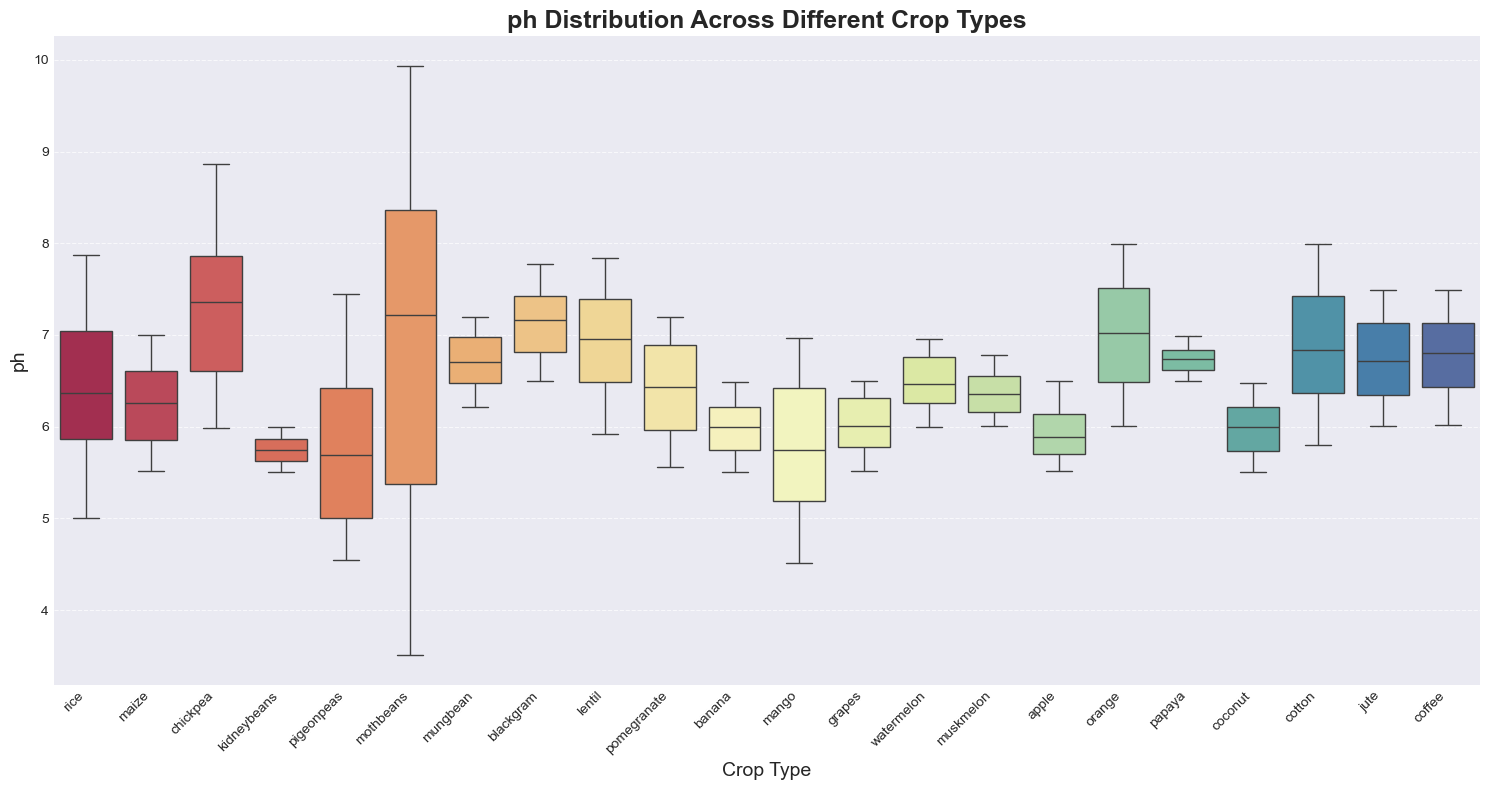

Insight for ph: These box plots are crucial for understanding the ideal range of values for 'ph' required by each specific crop. They visually highlight the distinct environmental and nutrient preferences of different crops. 🌱


/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/3050303824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feature, data=df, palette='Spectral')


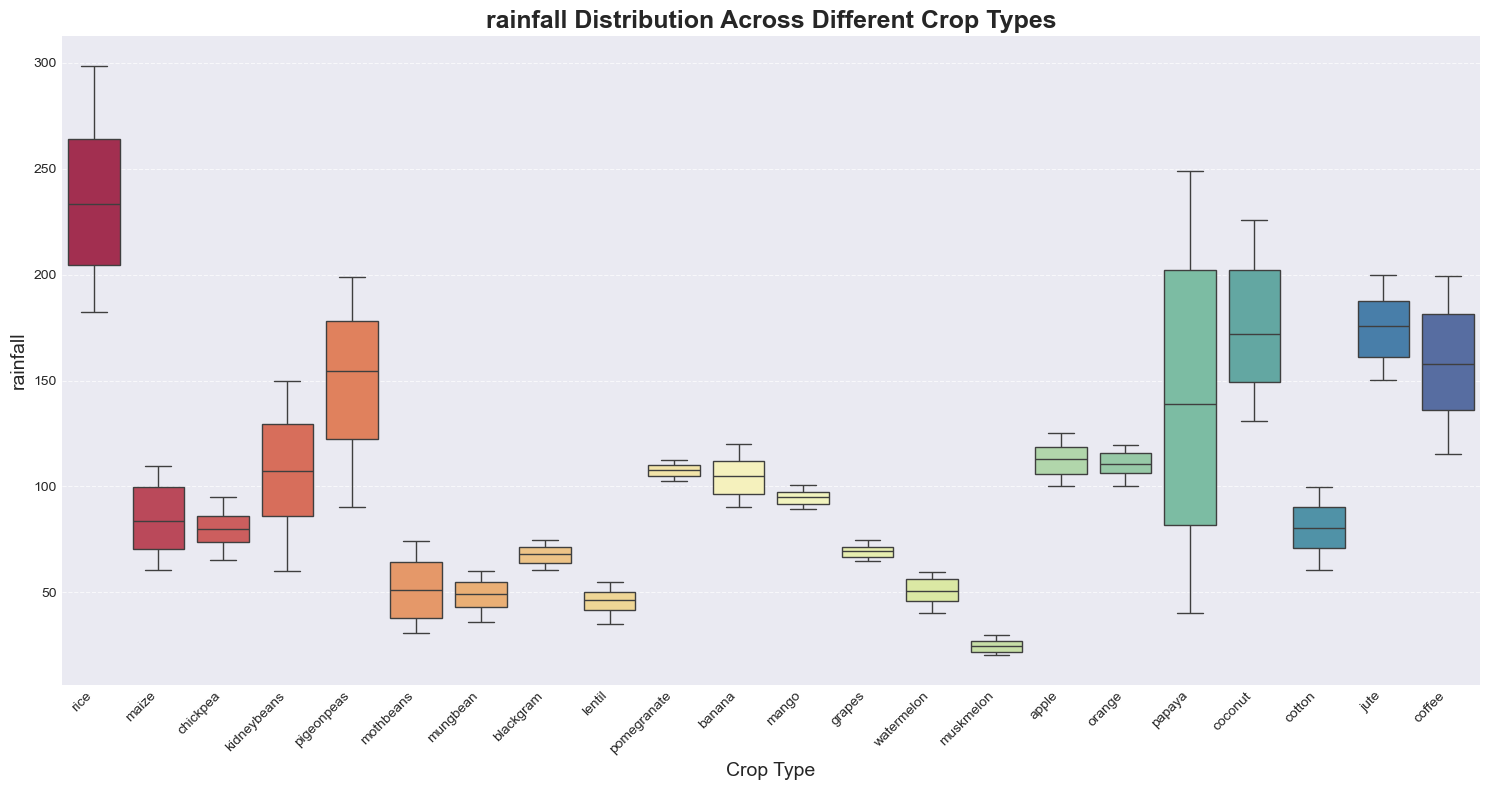

Insight for rainfall: These box plots are crucial for understanding the ideal range of values for 'rainfall' required by each specific crop. They visually highlight the distinct environmental and nutrient preferences of different crops. 🌱

Comprehensive EDA complete! These visualizations provide deep insights into the dataset, which is invaluable for building a robust crop recommendation model. 🎉


In [24]:
# --- 6. Bivariate Analysis: Box Plots showing Feature Distribution by Crop Type ---
print("\n--- Plotting: Feature Distribution Across Different Crop Types (Box Plots) ---")
# Generate box plots for each numerical feature, showing its distribution across different crop types
for feature in numerical_features:
    plt.figure(figsize=(15, 8))
    sns.boxplot(x='label', y=feature, data=df, palette='Spectral')
    plt.title(f'{feature} Distribution Across Different Crop Types', fontsize=18, fontweight='bold')
    plt.xlabel('Crop Type', fontsize=14)
    plt.ylabel(feature, fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels for better readability
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print(f"Insight for {feature}: These box plots are crucial for understanding the ideal range of values for '{feature}' required by each specific crop. They visually highlight the distinct environmental and nutrient preferences of different crops. 🌱")

print("\nComprehensive EDA complete! These visualizations provide deep insights into the dataset, which is invaluable for building a robust crop recommendation model. 🎉")

## since data set in already healthy -- we will proceed to Prepare the data for training

In [9]:
# The features (inputs) are the soil and environmental data
X = df[['N', 'P', 'K', 'ph', 'temperature', 'humidity', 'rainfall']]

# The target (what we want to predict) is the crop label
y = df['label']

# Split the data into a "Training Set" and a "Testing Set"

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1760, 7)
Testing data shape: (440, 7)


# Create and Train the Model

In [11]:
# Create the model instance
model = RandomForestClassifier(n_estimators=100, random_state=42)

# "Fit" the model to our training data
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


# Performance  Check 

In [12]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.09%


Generating Confusion Matrix Plot...


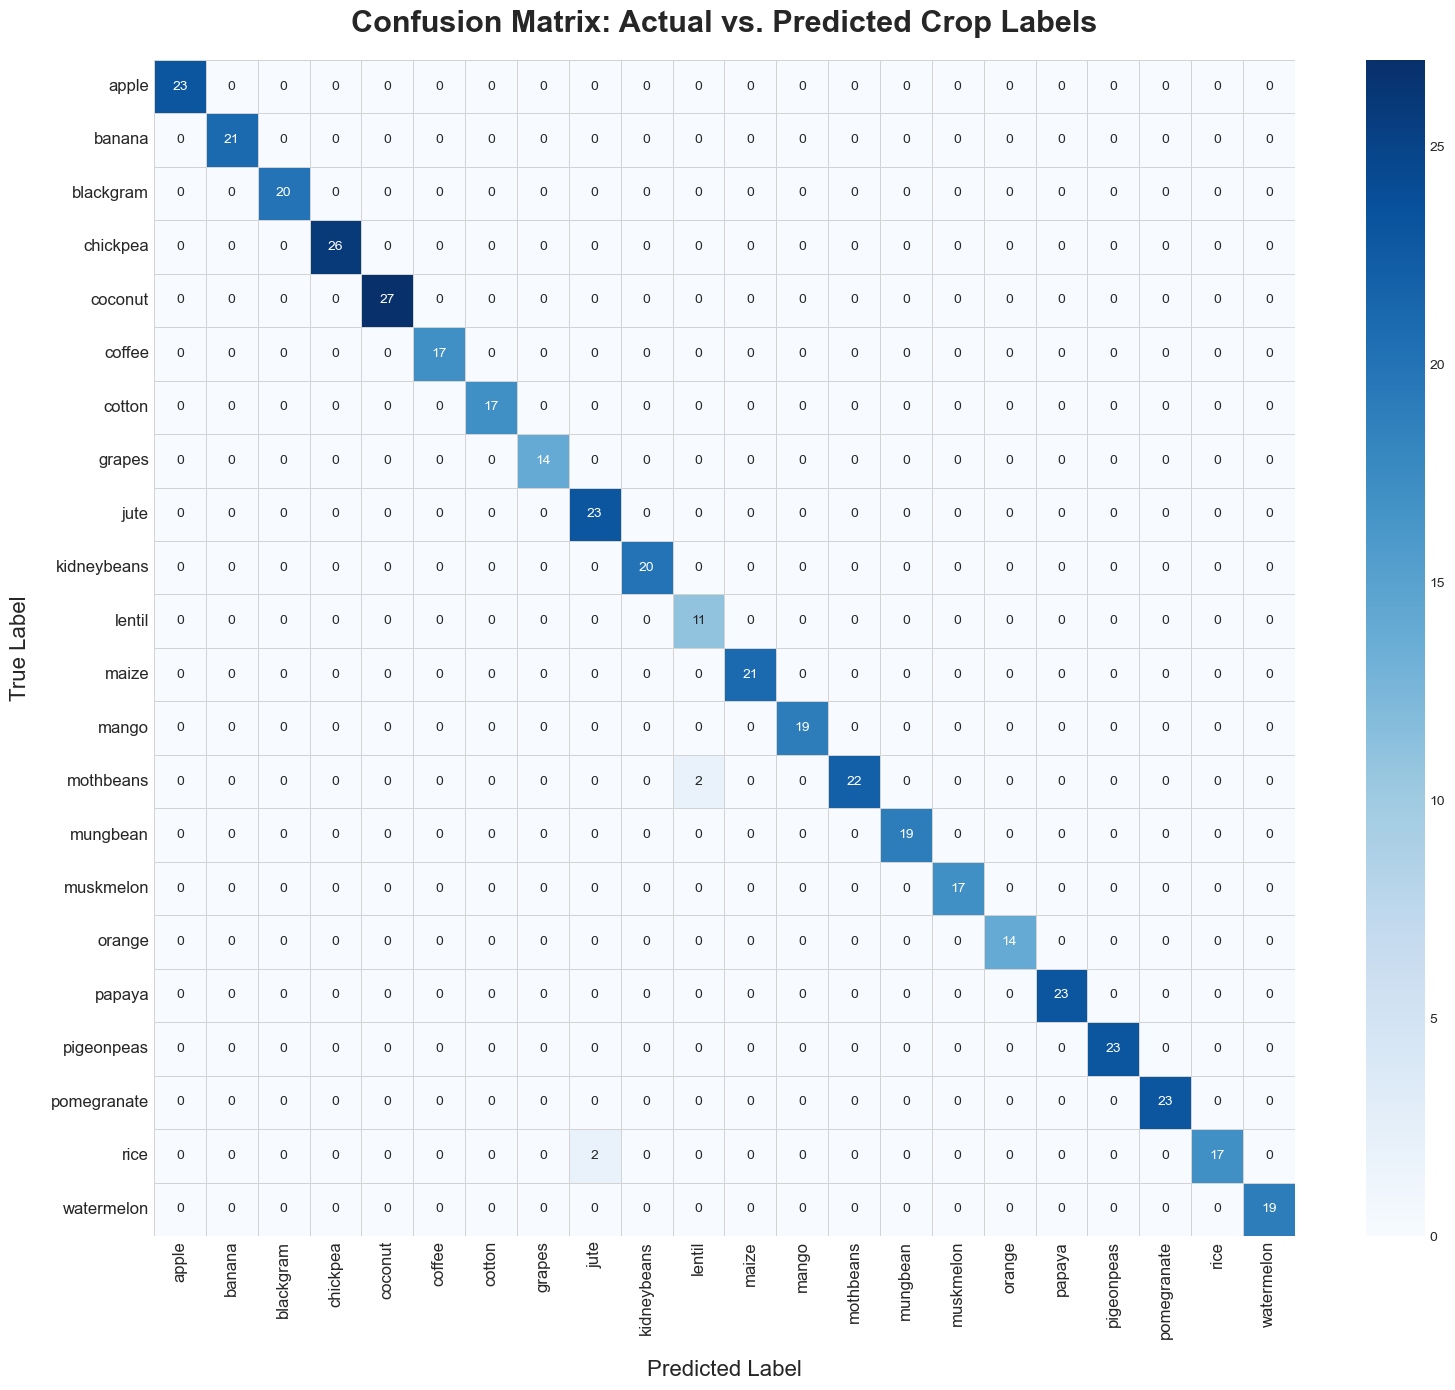

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# If not, please run your previous model training code first.
# X_test, X_train, y_test, y_train, y_pred, df, etc. should already exist.

# Get the unique crop labels for consistent ordering
labels = sorted(df['label'].unique())

# --- Confusion Matrix Plot ---
print("Generating Confusion Matrix Plot...")
plt.figure(figsize=(16, 14))
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=.5, linecolor='lightgray')
plt.title('Confusion Matrix: Actual vs. Predicted Crop Labels', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=16, labelpad=15)
plt.ylabel('True Label', fontsize=16, labelpad=15)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
# --- Classification Report Metrics as Graphs ---
print("\nGenerating Precision, Recall, and F1-Score Plots...")
report = classification_report(y_test, y_pred, target_names=labels, output_dict=True)



Generating Precision, Recall, and F1-Score Plots...


/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/242697329.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Score', data=metrics_melted[metrics_melted['Metric'] == metric],


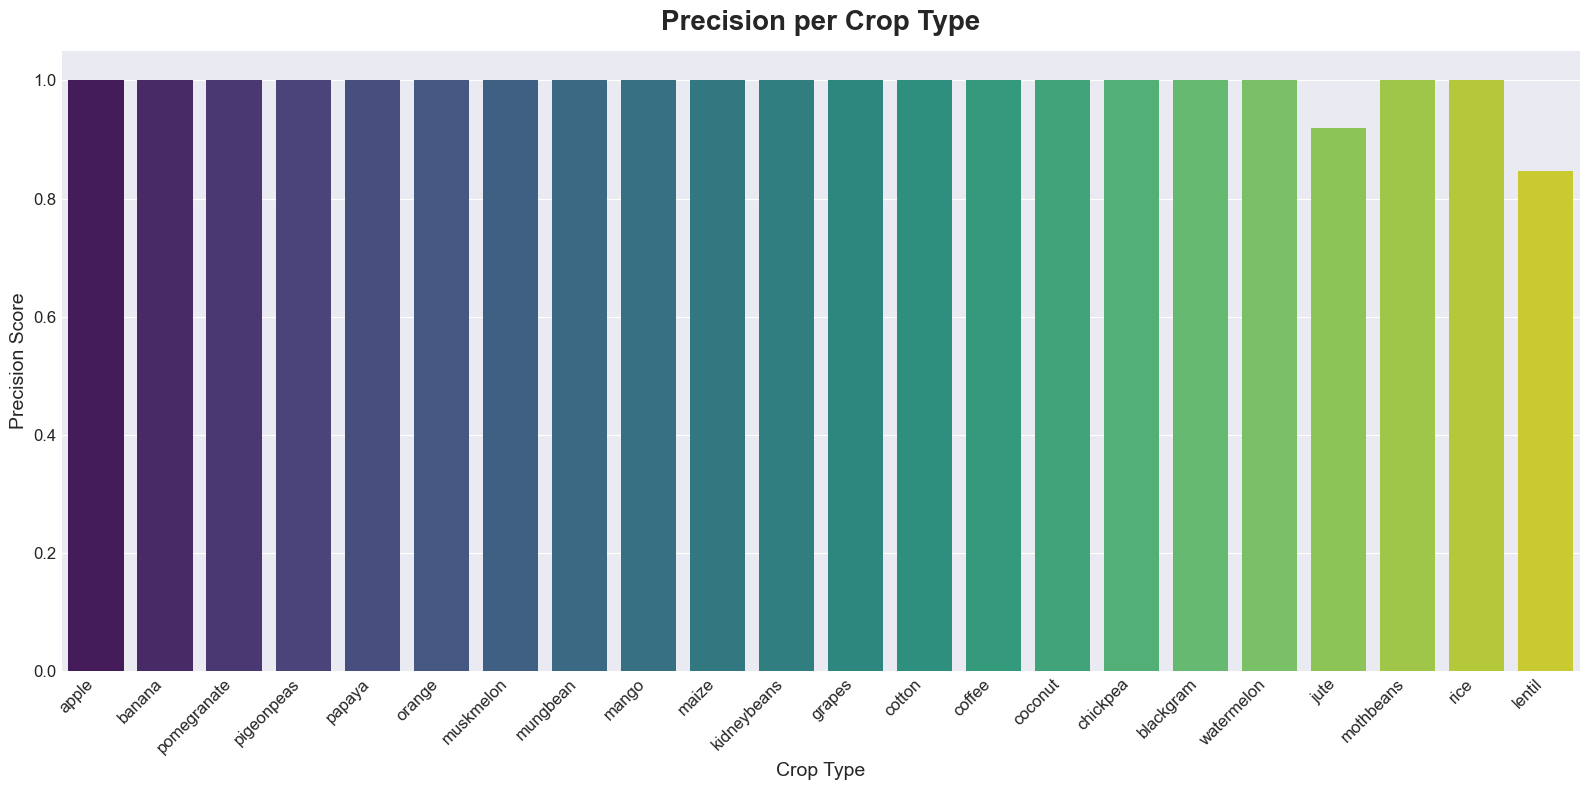

/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/242697329.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Score', data=metrics_melted[metrics_melted['Metric'] == metric],


Precision plot generated. ✅



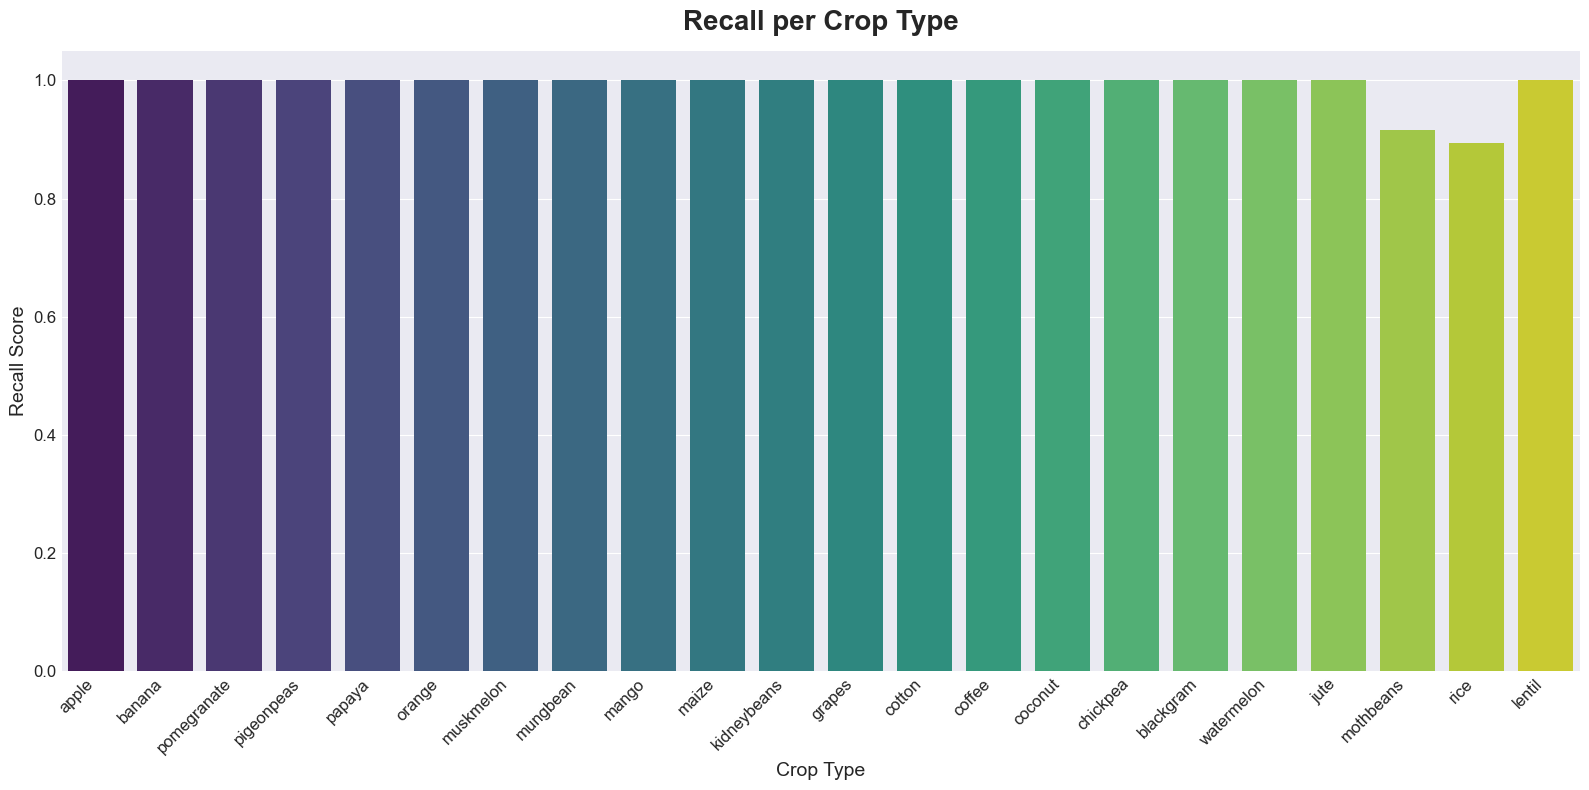

Recall plot generated. ✅



/var/folders/jd/5681g6rx58xgpr8txbqb17p80000gn/T/ipykernel_8187/242697329.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Score', data=metrics_melted[metrics_melted['Metric'] == metric],


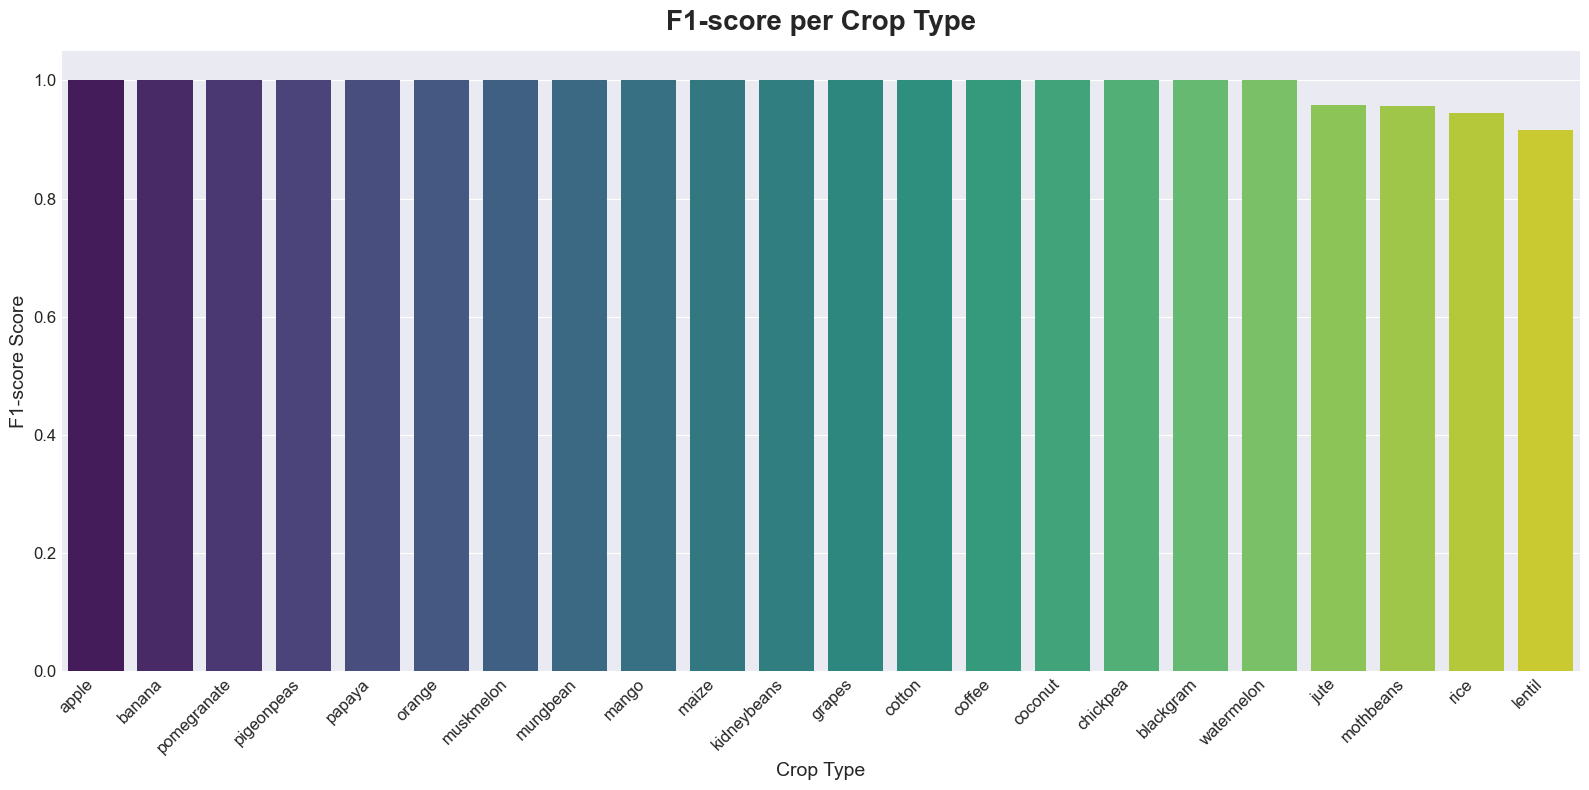

F1-score plot generated. ✅



In [27]:
# Convert the report to a DataFrame for easier plotting
metrics_df = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'])
metrics_df['Class'] = metrics_df.index
metrics_melted = metrics_df.melt(id_vars='Class', value_vars=['precision', 'recall', 'f1-score'],
                                 var_name='Metric', value_name='Score')

# Sort classes by F1-score for consistent plotting order
metrics_melted_sorted = metrics_melted[metrics_melted['Metric'] == 'f1-score'].sort_values(by='Score', ascending=False)
sorted_classes = metrics_melted_sorted['Class'].tolist()

# Plotting individual metrics
for metric in ['precision', 'recall', 'f1-score']:
    plt.figure(figsize=(16, 8))
    sns.barplot(x='Class', y='Score', data=metrics_melted[metrics_melted['Metric'] == metric],
                order=sorted_classes, palette='viridis')
    plt.title(f'{metric.capitalize()} per Crop Type', fontsize=20, fontweight='bold', pad=15)
    plt.xlabel('Crop Type', fontsize=14)
    plt.ylabel(f'{metric.capitalize()} Score', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0.0, 1.05)
    plt.tight_layout()
    plt.show()
    print(f"{metric.capitalize()} plot generated. ✅\n")

Generating Combined Precision, Recall, and F1-Score Plot...


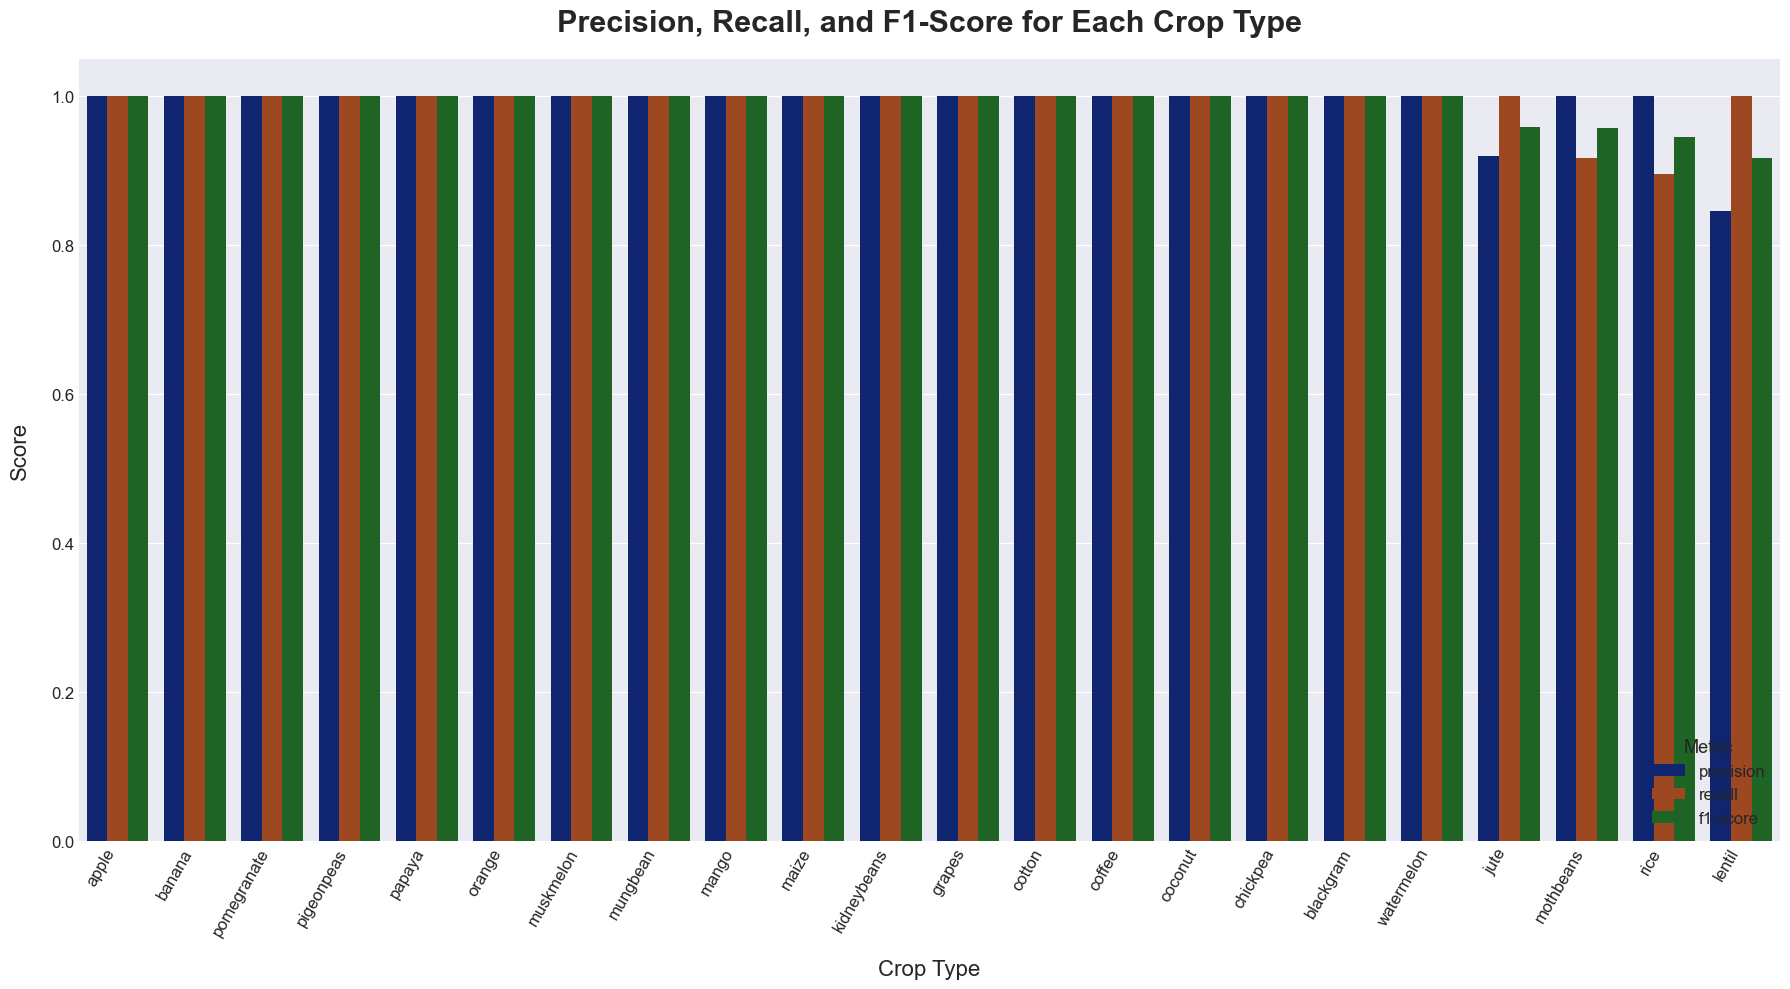

Combined plot generated. ✅

All performance visualizations generated successfully! ✨


In [28]:
# --- Optional: Combined Metrics Plot ---
print("Generating Combined Precision, Recall, and F1-Score Plot...")
plt.figure(figsize=(18, 10))
sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_melted,
            order=sorted_classes, palette='dark')
plt.title('Precision, Recall, and F1-Score for Each Crop Type', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Crop Type', fontsize=16, labelpad=15)
plt.ylabel('Score', fontsize=16, labelpad=15)
plt.xticks(rotation=60, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.0, 1.05)
plt.legend(title='Metric', title_fontsize='13', fontsize='12', loc='lower right')
plt.tight_layout()
plt.show()
print("Combined plot generated. ✅\n")

print("All performance visualizations generated successfully! ✨")


# Save the trained model to a file

In [29]:
# Construct the path to save the model in the 'src' directory
model_path = os.path.join('..', 'src', 'crop_recommendation_model.pkl')

# Save the model object
joblib.dump(model, model_path)

print(f"Model saved to {model_path}")

Model saved to ../src/crop_recommendation_model.pkl
